#### Taxi trip pricing

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [30]:
data = pd.read_csv('taxi_trip_pricing.csv')
data

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [32]:
data['Time_of_Day'].value_counts()

Time_of_Day
Afternoon    371
Morning      283
Evening      203
Night         93
Name: count, dtype: int64

In [33]:
data['Day_of_Week'].value_counts()

Day_of_Week
Weekday    655
Weekend    295
Name: count, dtype: int64

In [34]:
data['Traffic_Conditions'].value_counts()

Traffic_Conditions
Low       397
Medium    371
High      182
Name: count, dtype: int64

In [35]:
data['Weather'].value_counts()

Weather
Clear    667
Rain     227
Snow      56
Name: count, dtype: int64

In [36]:
data.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [37]:
data = pd.get_dummies(data, columns = ['Time_of_Day'], dtype = 'int8')

In [38]:
data = pd.get_dummies(data, columns = ['Day_of_Week'], dtype = 'int8')

In [39]:
data = pd.get_dummies(data, columns = ['Traffic_Conditions'], dtype = 'int8')

In [40]:
data = pd.get_dummies(data, columns = ['Weather'], dtype = 'int8')

In [41]:
data

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekday,Day_of_Week_Weekend,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Clear,Weather_Rain,Weather_Snow
0,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,0,0,1,0,1,0,0,1,0,1,0,0
1,47.59,1.0,NaN,0.62,0.43,40.57,NaN,1,0,0,0,1,0,1,0,0,1,0,0
2,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,0,1,0,0,0,1,1,0,0,1,0,0
3,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,0,1,0,0,1,0,0,1,0,0,0,0
4,NaN,3.0,2.93,0.63,0.32,22.64,15.6180,0,1,0,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,4.0,2.39,0.62,0.49,58.39,34.4049,1,0,0,0,0,1,0,0,1,1,0,0
996,45.95,4.0,3.12,0.61,NaN,61.96,62.1295,0,0,0,1,1,0,0,0,1,1,0,0
997,7.70,3.0,2.08,1.78,NaN,54.18,33.1236,0,0,1,0,1,0,0,1,0,0,1,0
998,47.56,1.0,2.67,0.82,0.17,114.94,61.2090,0,0,1,0,1,0,0,1,0,1,0,0


In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Trip_Distance_km           950 non-null    float64
 1   Passenger_Count            950 non-null    float64
 2   Base_Fare                  950 non-null    float64
 3   Per_Km_Rate                950 non-null    float64
 4   Per_Minute_Rate            950 non-null    float64
 5   Trip_Duration_Minutes      950 non-null    float64
 6   Trip_Price                 951 non-null    float64
 7   Time_of_Day_Afternoon      1000 non-null   int8   
 8   Time_of_Day_Evening        1000 non-null   int8   
 9   Time_of_Day_Morning        1000 non-null   int8   
 10  Time_of_Day_Night          1000 non-null   int8   
 11  Day_of_Week_Weekday        1000 non-null   int8   
 12  Day_of_Week_Weekend        1000 non-null   int8   
 13  Traffic_Conditions_High    1000 non-null   int8  

In [47]:
print(data['Trip_Distance_km'].mean())
print(data['Passenger_Count'].mean())

27.07054686176132
2.4768421052631577


In [45]:
data['Trip_Distance_km'] = data['Trip_Distance_km'].fillna(data['Trip_Distance_km'].mean())

In [48]:
data['Base_Fare'] = data['Base_Fare'].fillna(data['Base_Fare'].mean())

In [49]:
data['Per_Km_Rate'] = data['Per_Km_Rate'].fillna(data['Per_Km_Rate'].mean())
data['Per_Minute_Rate'] = data['Per_Minute_Rate'].fillna(data['Per_Minute_Rate'].mean())
data['Trip_Duration_Minutes'] = data['Trip_Duration_Minutes'].fillna(data['Trip_Duration_Minutes'].mean())
data['Trip_Price'] = data['Trip_Price'].fillna(data['Trip_Price'].mean())

In [50]:
data['Passenger_Count'] = data['Passenger_Count'].fillna(method = 'ffill')

C:\Users\Anna\AppData\Local\Temp\ipykernel_14684\2677047611.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['Passenger_Count'] = data['Passenger_Count'].fillna(method = 'ffill')


In [51]:
data

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekday,Day_of_Week_Weekend,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Clear,Weather_Rain,Weather_Snow
0,19.350000,3.0,3.560000,0.800000,0.320000,53.82,36.262400,0,0,1,0,1,0,0,1,0,1,0,0
1,47.590000,1.0,3.502989,0.620000,0.430000,40.57,56.874773,1,0,0,0,1,0,1,0,0,1,0,0
2,36.870000,1.0,2.700000,1.210000,0.150000,37.27,52.903200,0,1,0,0,0,1,1,0,0,1,0,0
3,30.330000,4.0,3.480000,0.510000,0.150000,116.81,36.469800,0,1,0,0,1,0,0,1,0,0,0,0
4,27.070547,3.0,2.930000,0.630000,0.320000,22.64,15.618000,0,1,0,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,4.0,2.390000,0.620000,0.490000,58.39,34.404900,1,0,0,0,0,1,0,0,1,1,0,0
996,45.950000,4.0,3.120000,0.610000,0.292916,61.96,62.129500,0,0,0,1,1,0,0,0,1,1,0,0
997,7.700000,3.0,2.080000,1.780000,0.292916,54.18,33.123600,0,0,1,0,1,0,0,1,0,0,1,0
998,47.560000,1.0,2.670000,0.820000,0.170000,114.94,61.209000,0,0,1,0,1,0,0,1,0,1,0,0


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Trip_Distance_km           1000 non-null   float64
 1   Passenger_Count            1000 non-null   float64
 2   Base_Fare                  1000 non-null   float64
 3   Per_Km_Rate                1000 non-null   float64
 4   Per_Minute_Rate            1000 non-null   float64
 5   Trip_Duration_Minutes      1000 non-null   float64
 6   Trip_Price                 1000 non-null   float64
 7   Time_of_Day_Afternoon      1000 non-null   int8   
 8   Time_of_Day_Evening        1000 non-null   int8   
 9   Time_of_Day_Morning        1000 non-null   int8   
 10  Time_of_Day_Night          1000 non-null   int8   
 11  Day_of_Week_Weekday        1000 non-null   int8   
 12  Day_of_Week_Weekend        1000 non-null   int8   
 13  Traffic_Conditions_High    1000 non-null   int8  

In [54]:
data.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekday,Day_of_Week_Weekend,Traffic_Conditions_High,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Clear,Weather_Rain,Weather_Snow
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,27.070547,2.483000,3.502989,1.233316,0.292916,62.118116,56.874773,0.371000,0.203000,0.283000,0.093000,0.655000,0.295000,0.182000,0.397000,0.371000,0.667000,0.227000,0.056000
std,19.400775,1.101328,0.848107,0.418922,0.112662,31.339413,39.464810,0.483314,0.402434,0.450682,0.290578,0.475606,0.456271,0.386038,0.489521,0.483314,0.471522,0.419102,0.230037
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.107500,2.000000,2.770000,0.870000,0.197500,37.107500,34.578850,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.995000,2.000000,3.502989,1.233316,0.292916,62.118116,52.617000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,37.782500,3.000000,4.202500,1.580000,0.382500,87.775000,67.476650,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [55]:
y = data['Trip_Price']
x = data.drop(['Trip_Price'], axis = 1)

In [57]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.15, random_state=1)

In [59]:
sc = StandardScaler()
x_train_sc = pd.DataFrame(sc.fit_transform(x_train), columns = x_train.columns, index = x_train.index)
x_test_sc = pd.DataFrame(sc.transform(x_test), columns = x_test.columns, index = x_test.index)

#### Linear Regression

In [63]:
model = LinearRegression()
model.fit(x_train_sc, y_train)
y_train_pred = model.predict(x_train_sc)
y_test_pred = model.predict(x_test_sc)
print("MAE_train: ", mean_absolute_error(y_train, y_train_pred))
print("MAE_test: ", mean_absolute_error(y_train, y_train_pred))
print("MSE_train: ", mean_squared_error(y_train, y_train_pred))
print("MSE_test: ", mean_squared_error(y_train, y_train_pred))
print("RMSE_train: ", root_mean_squared_error(y_train, y_train_pred))
print("RMSE_train: ", root_mean_squared_error(y_train, y_train_pred))

MAE_train:  10.581642508267393
MAE_test:  10.581642508267393
MSE_train:  265.3042239222737
MSE_test:  265.3042239222737
RMSE_train:  16.288162079322323
RMSE_train:  16.288162079322323


#### Decision tree

In [81]:
model_dt = DecisionTreeRegressor(max_depth=4, min_samples_split=2, min_samples_leaf=1)
model_dt.fit(x_train_sc, y_train)
y_train_pred = model_dt.predict(x_train_sc)
y_test_pred = model_dt.predict(x_test_sc)
print("MAE_train: ", mean_absolute_error(y_train, y_train_pred))
print("MAE_test: ", mean_absolute_error(y_train, y_train_pred))
print("MSE_train: ", mean_squared_error(y_train, y_train_pred))
print("MSE_test: ", mean_squared_error(y_train, y_train_pred))
print("RMSE_train: ", root_mean_squared_error(y_train, y_train_pred))
print("RMSE_train: ", root_mean_squared_error(y_train, y_train_pred))

MAE_train:  10.859435197274482
MAE_test:  10.859435197274482
MSE_train:  190.78249380613633
MSE_test:  190.78249380613633
RMSE_train:  13.812403621605341
RMSE_train:  13.812403621605341


#### Random Forest

In [82]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=4, min_samples_split=2, min_samples_leaf=1)
model_rf.fit(x_train_sc, y_train)
y_train_pred = model_rf.predict(x_train_sc)
y_test_pred = model_rf.predict(x_test_sc)
print("MAE_train: ", mean_absolute_error(y_train, y_train_pred))
print("MAE_test: ", mean_absolute_error(y_train, y_train_pred))
print("MSE_train: ", mean_squared_error(y_train, y_train_pred))
print("MSE_test: ", mean_squared_error(y_train, y_train_pred))
print("RMSE_train: ", root_mean_squared_error(y_train, y_train_pred))
print("RMSE_train: ", root_mean_squared_error(y_train, y_train_pred))

MAE_train:  9.515705721143382
MAE_test:  9.515705721143382
MSE_train:  152.56276819094455
MSE_test:  152.56276819094455
RMSE_train:  12.351630183540331
RMSE_train:  12.351630183540331


In [86]:
y_train.shape, y_train_pred.shape

((850,), (850,))

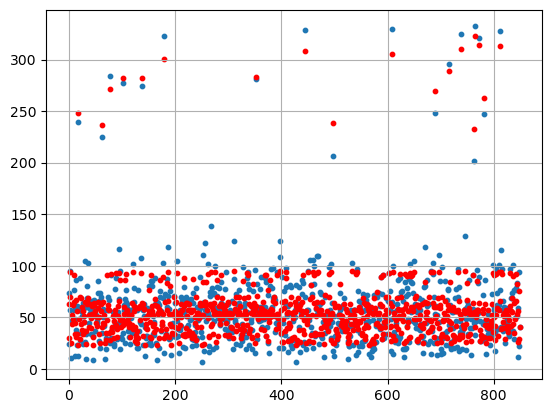

In [90]:
plt.scatter(range(850), y_train, s = 10)
plt.scatter(range(850), y_train_pred, c = 'r', s = 10)
plt.grid()

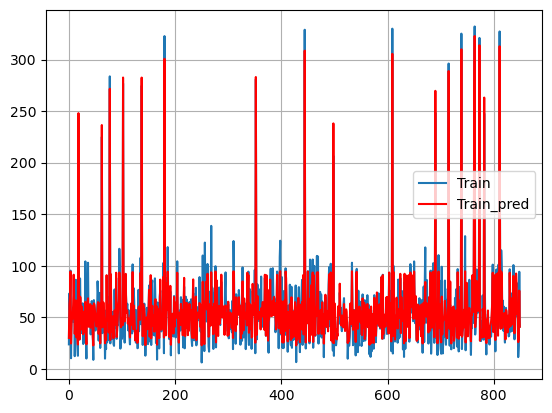

In [94]:
plt.plot(range(850), y_train, label = 'Train')
plt.plot(range(850), y_train_pred, c = 'r', label = 'Train_pred')
plt.legend()
plt.grid()
plt.show()